# Urban Eats - Y Profilling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df =pd.read_csv("/content/drive/MyDrive/Colab Notebooks/urbaneats_delivery_orders.csv")

In [3]:
df.head()

,order_id,order_date,restaurant_name,delivery_zone,order_value,delivery_time_mins,rider_rating,order_status,payment_method,discount_applied,customer_complaints
0,ORD00001,2024-09-25,Pizza Palace,North,1705.0,NaN,3.0,Delayed,Cash,12.0,0
1,ORD00002,2024-03-11,Pizza Palace,East,807.0,NaN,4.2,Cancelled,Card,12.0,3
2,ORD00003,2024-12-11,Spice Garden,South,466.0,NaN,3.6,Delayed,Card,1.0,3
3,ORD00004,2024-07-10,Wrap & Roll,East,675.0,NaN,3.6,Delivered,UPI,3.0,0
4,ORD00005,2024-03-15,Wrap & Roll,North,349.0,NaN,2.0,Refunded,Cash,20.0,0


In [4]:
import sys
!{sys.executable} -m pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.5 MB/s eta 0:00:00


In [5]:
from ydata_profiling import ProfileReport

/tmp/ipykernel_8874/44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [6]:

profile = ProfileReport(df, title='UrbanEats Operations Audit', explorative=True)
profile.to_file("urban_eats_assessment.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 67.95it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

 ### Q.1 How many orders are missing delivery_time_mins, and which order_status values are they concentrated in?

In [11]:
df['order_status'].value_counts()

,count
order_status,
Delivered,44
Refunded,37
Cancelled,36
Delayed,33


In [10]:
df[df['delivery_time_mins'].isna()]['order_status'].value_counts()

,count
order_status,
Delayed,2
Delivered,2
Cancelled,1
Refunded,1


# Ans:
 - from `usrba_eats_assessment.html`we got these values:
    - `delivery_time_mins` missing values : 6.
    -  `order_status` has these values:
        - `Delayed` : 2
        - `Delivered` : 2
        - `Cancelled` : 1
        - `Refunded` : 1

## Q.2 •	How many orders are missing rider_rating? Is there a pattern (e.g. concentrated in Cancelled orders)?

In [13]:
df['rider_rating'].isna().sum()

np.int64(6)

In [16]:
df.groupby('order_status')['customer_complaints'].sum()

,customer_complaints
order_status,
Cancelled,48
Delayed,42
Delivered,65
Refunded,50


In [15]:
df[df['rider_rating'].isna()]

,order_id,order_date,restaurant_name,delivery_zone,order_value,delivery_time_mins,rider_rating,order_status,payment_method,discount_applied,customer_complaints
6,ORD00007,2024-05-09,Pizza Palace,East,423.0,53.0,NaN,Cancelled,Cash,2.0,0
7,ORD00008,2024-12-04,Burger Hub,North,134.0,80.0,NaN,Cancelled,Card,1.0,2
8,ORD00009,2024-11-10,Sushi Bay,East,1559.0,54.0,NaN,Delivered,Card,25.0,2
9,ORD00010,2024-09-24,Sushi Bay,West,733.0,25.0,NaN,Delivered,Cash,8.0,1
10,ORD00011,2024-08-20,Pizza Palace,West,1157.0,75.0,NaN,Refunded,Wallet,25.0,1
11,ORD00012,2024-03-14,Spice Garden,East,806.0,66.0,NaN,Delivered,UPI,19.0,3


# Ans:
 - from `usrba_eats_assessment.html`we got these values:
    - `rider_rating` missing values : 6.
    -  `order_status` has these values:
        - `Delivered` : 3
        - `Cancelled` : 2
        - `Refunded` : 1
    - Almost all the missing rating got at least 1 complaint except one cancelled one.


## Q.3 •	What is the distribution of order_status? What percentage are Cancelled or Refunded?

In [19]:
df['order_status'].describe()

,order_status
count,150
unique,4
top,Delivered
freq,44


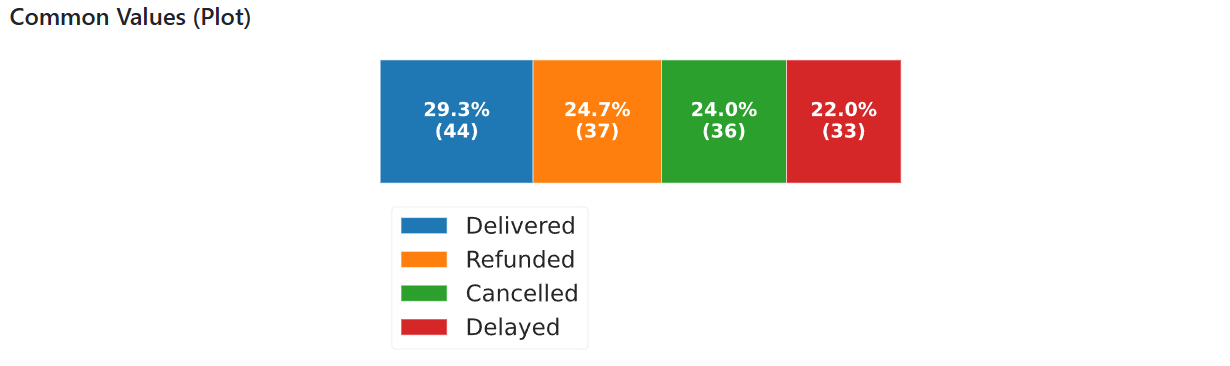

# Ans:
 - Total 150 count of `order_status`
 - Total `Cancelled + Refunded` Orders are :  37 + 36 = 73
 -  ( 73/150 ) * 100 = 48.67%
 - almost half of the orders are getting cancelled or refunded.


## Q.4 Is order_value always positive? Are there any zero-value orders?

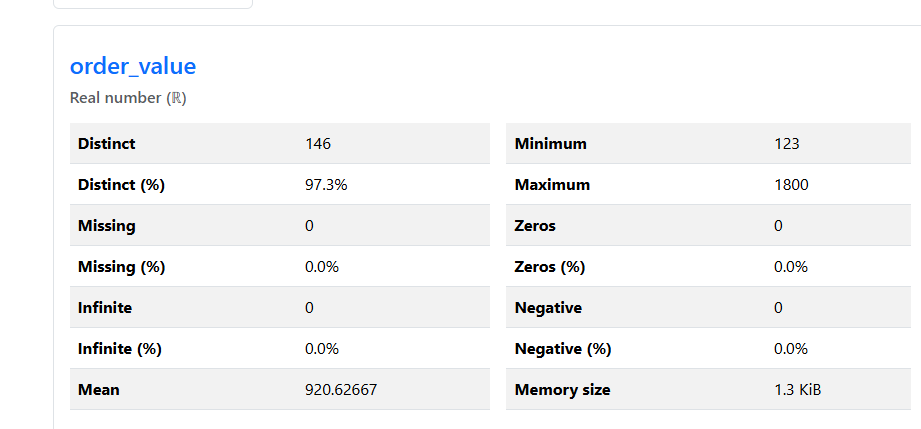

# Ans:
 - We have have no zero values nor negative values. it has allpositive values.

## Q.4 Write one sentence for the VP explaining which missing field would most distort the delivery time analysis and why.

# Ans:
 - Missing value of `delivery_time_mins`  will be the most distorning value for analysis, as we measuring the delivery time with it.
